# Magdy Mohamed

# Data Description :

# Attribute Information
1-Age: age of the patient [years]

2-Sex: sex of the patient [M: Male, F: Female]

3-ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

4-RestingBP: resting blood pressure [mm Hg]

5-Cholesterol: serum cholesterol [mm/dl]

6-FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

7-RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

8-MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]

9-ExerciseAngina: exercise-induced angina [Y: Yes, N: No]

10-Oldpeak: oldpeak = ST [Numeric value measured in depression]

11-ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]

12-HeartDisease: output class [1: heart disease, 0: Normal]

# Context
Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.

# Importing libraries :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import the dataset

In [2]:
df=pd.read_csv('/content/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [6]:
df.duplicated().sum()

0

<ipython-input-7-b753ba4276b6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  heartDisease_countplot = sns.countplot(x=df.HeartDisease,palette=["#CD5C5C","#BDB76B"])
<ipython-input-7-b753ba4276b6>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  heartDisease_countplot.set_xticklabels(['No', 'Yes'], fontsize=20)


[Text(0, 0, 'No'), Text(1, 0, 'Yes')]

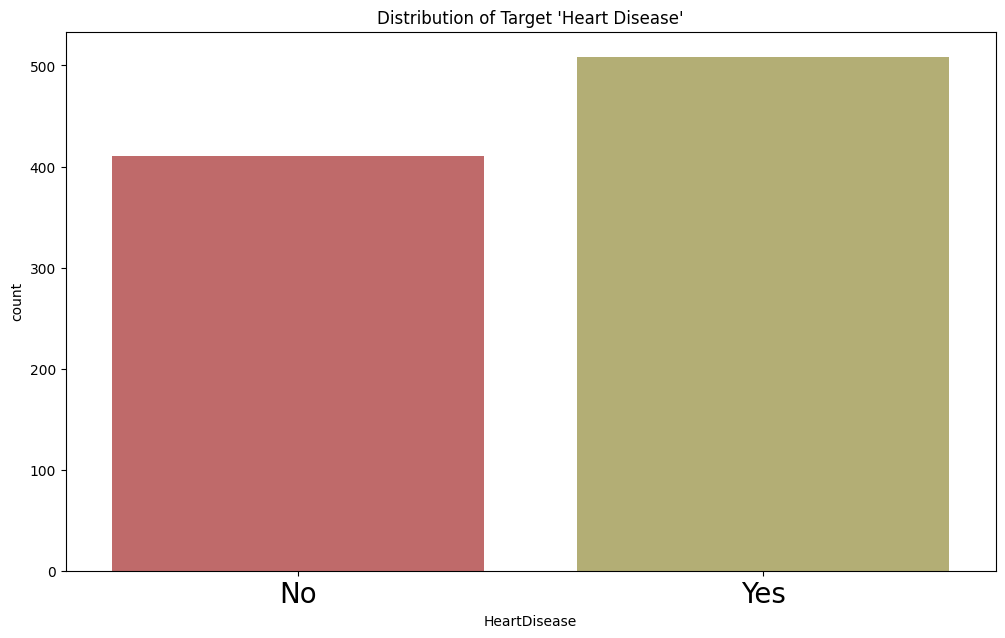

In [7]:
plt.figure(figsize=(12, 7))
heartDisease_countplot = sns.countplot(x=df.HeartDisease,palette=["#CD5C5C","#BDB76B"])
heartDisease_countplot.set_title("Distribution of Target 'Heart Disease'")
heartDisease_countplot.set_xticklabels(['No', 'Yes'], fontsize=20)

<ipython-input-8-0a8d52a6a10e>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Sex' , palette=['pink','brown']);


Text(0, 0.5, 'Count')

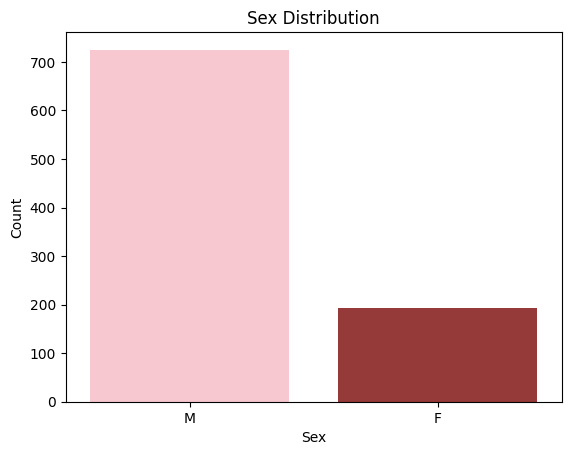

In [8]:
sns.countplot(data=df,x='Sex' , palette=['pink','brown']);
plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')

In [9]:
Categorical = df.select_dtypes(include=['object'])
Numerical = df.select_dtypes(include=['int64', 'float64'])

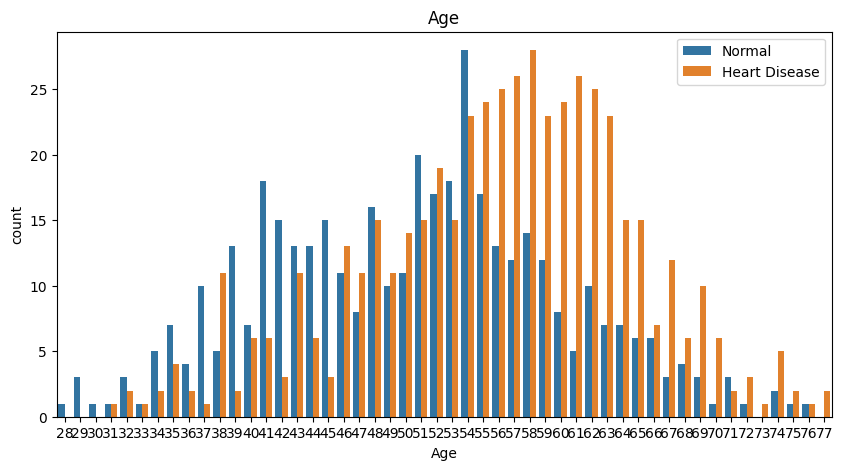

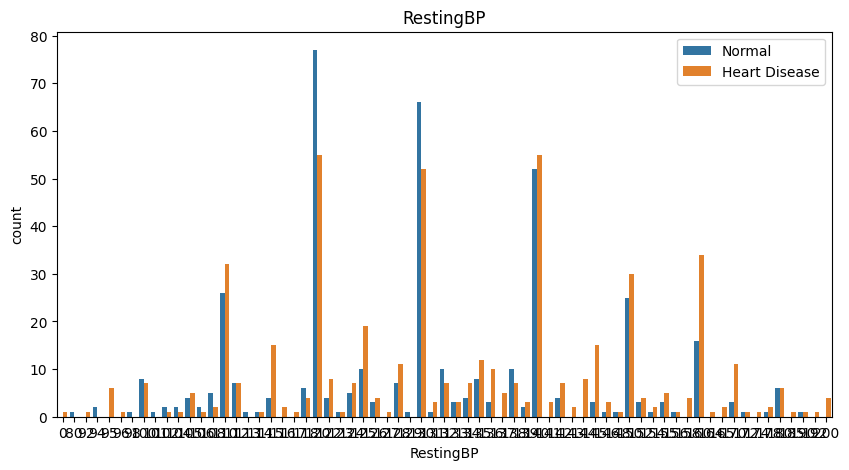

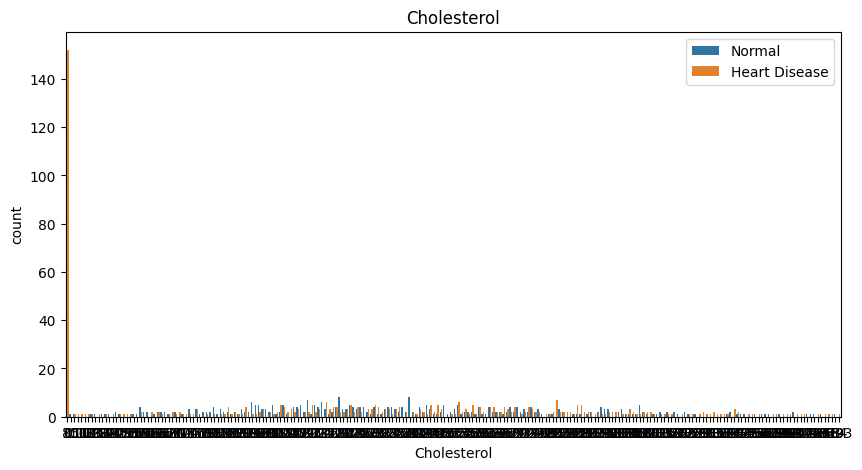

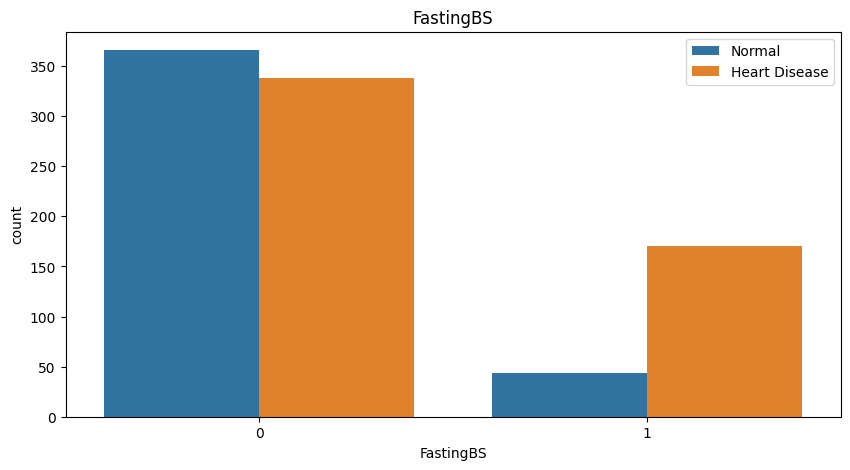

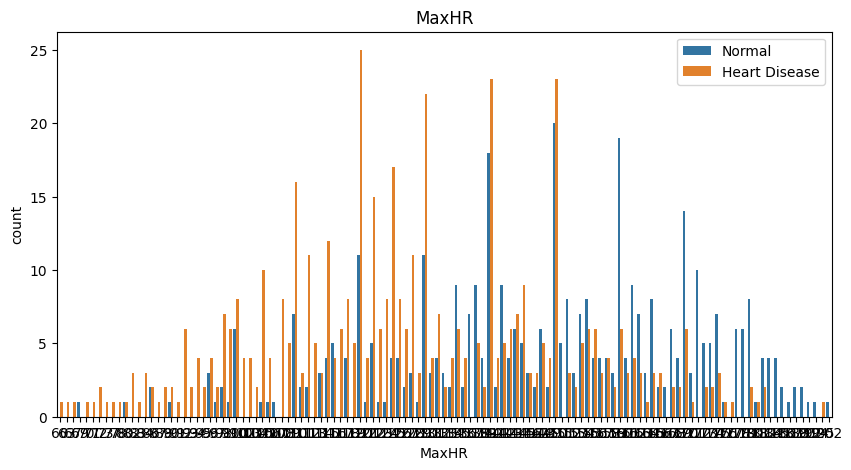

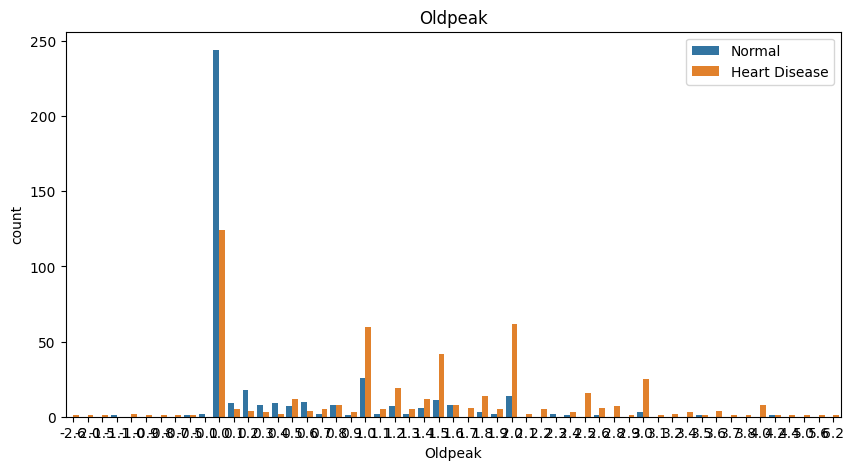

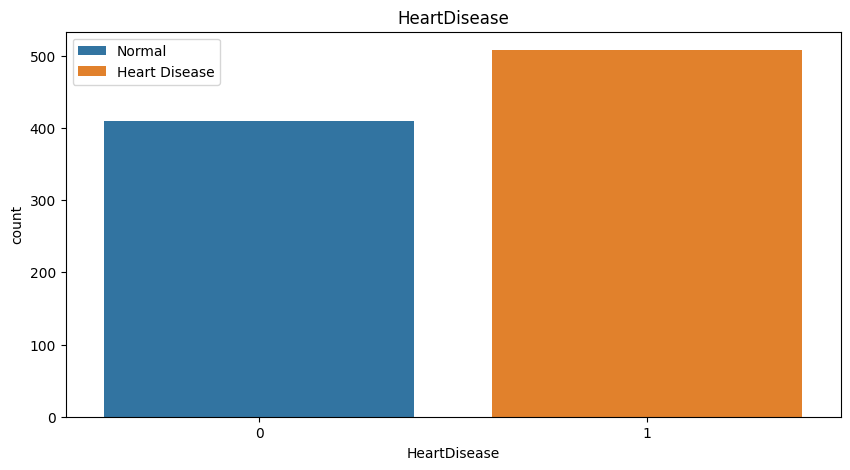

In [10]:
# ploting numerical features with target
#here we compare betwwen our target and our numerical features
for i in Numerical:
    plt.figure(figsize=(10,5))
    sns.countplot(x=i, data=df, hue='HeartDisease')
    plt.legend(['Normal', 'Heart Disease'])
    plt.title(i)
    plt.show()

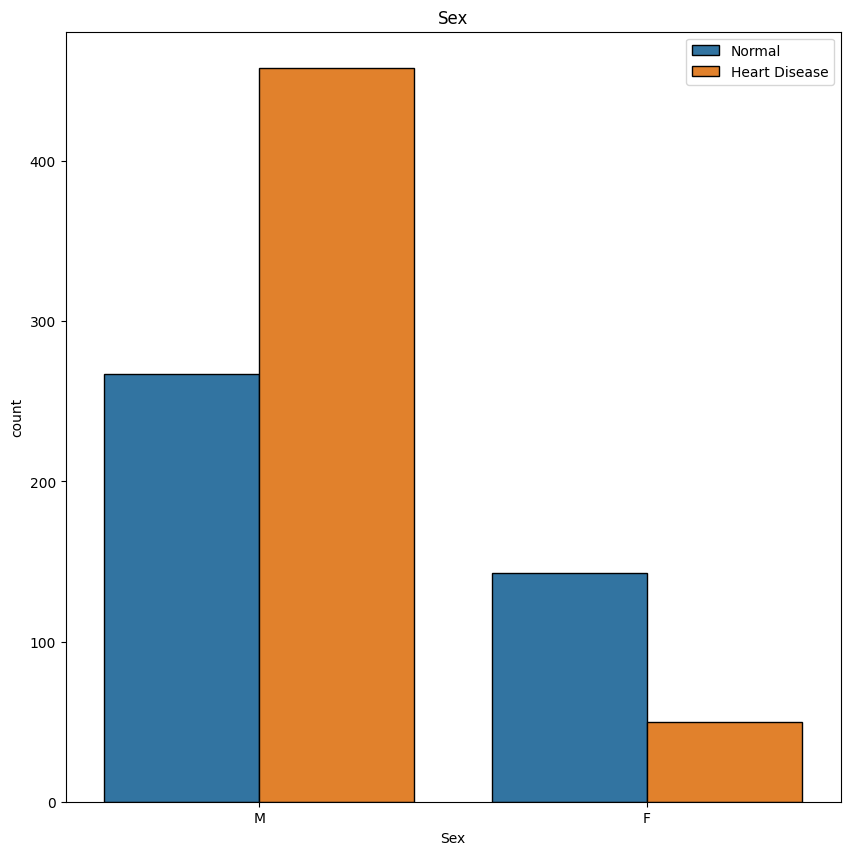

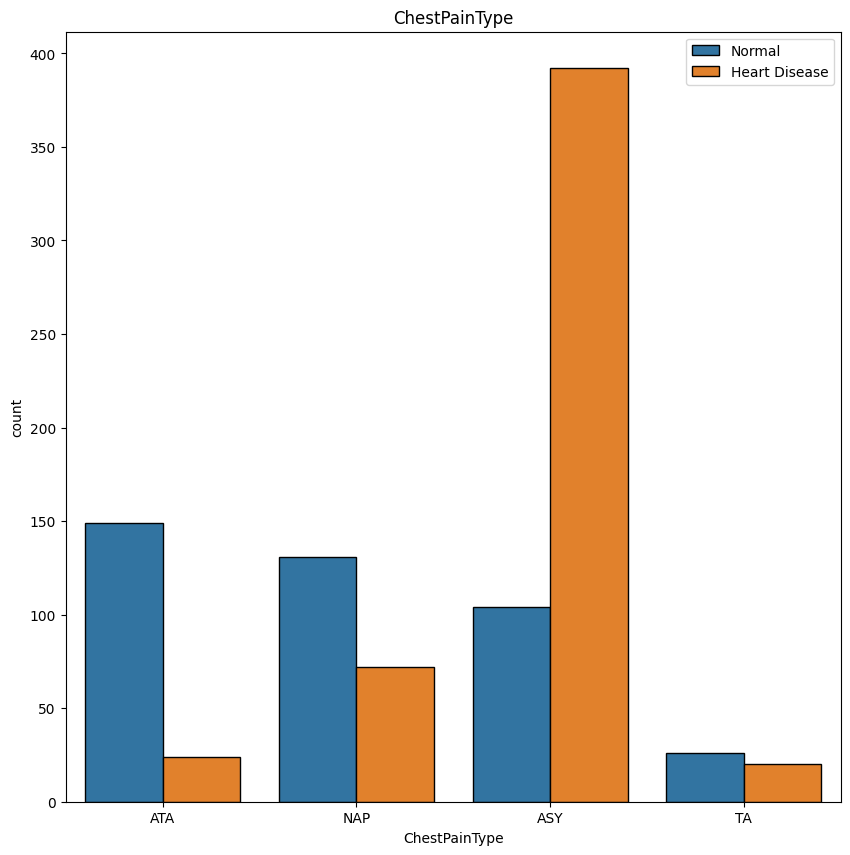

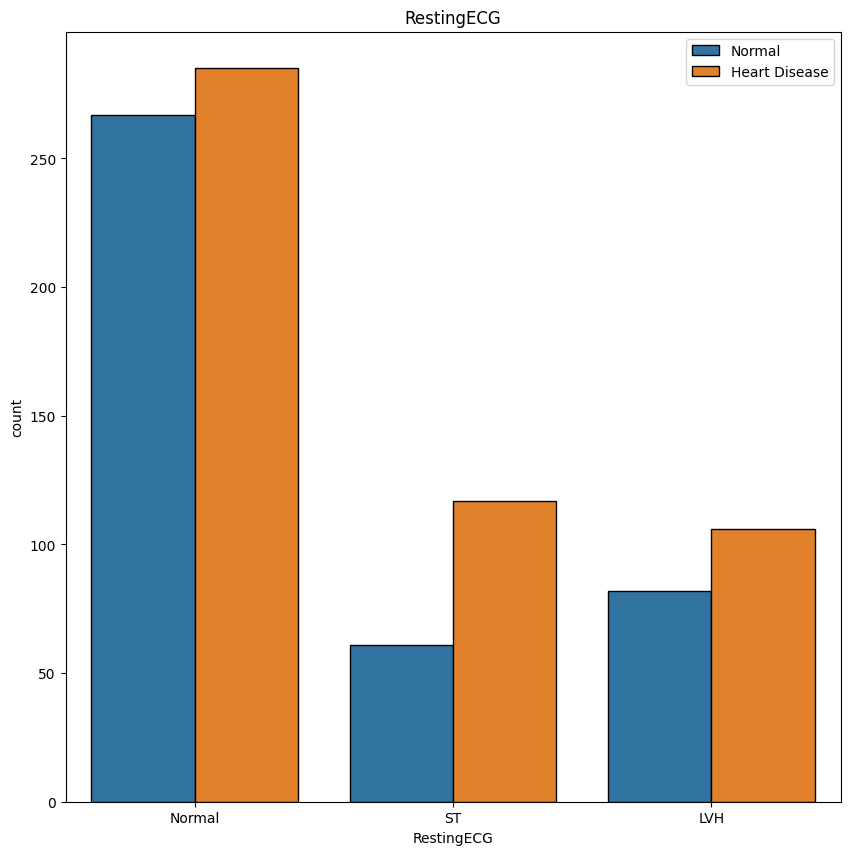

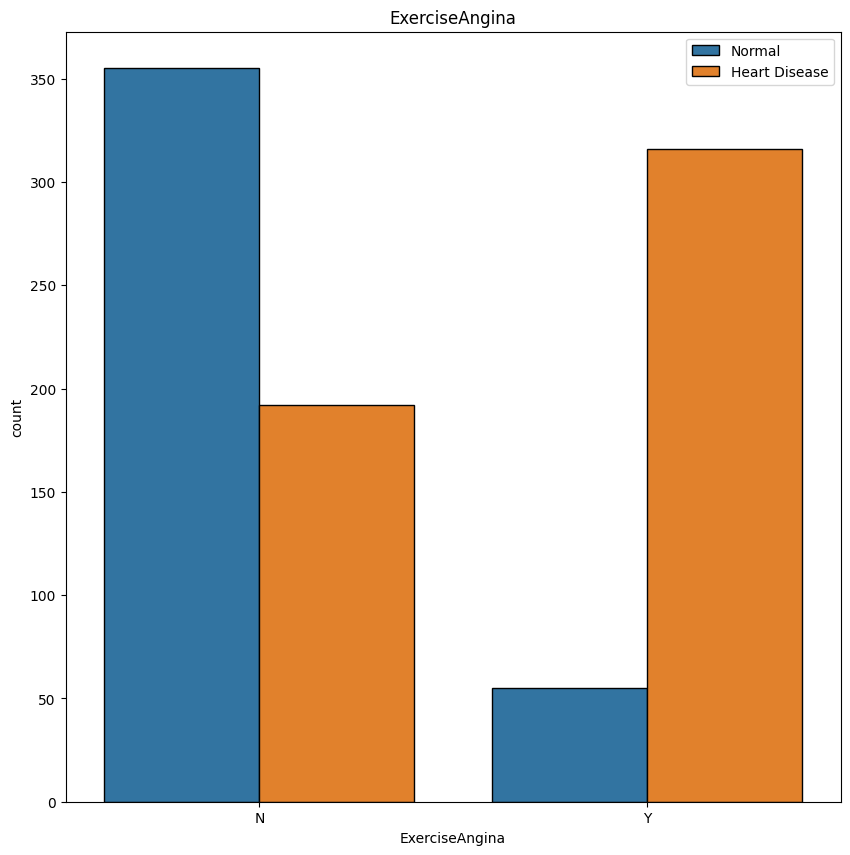

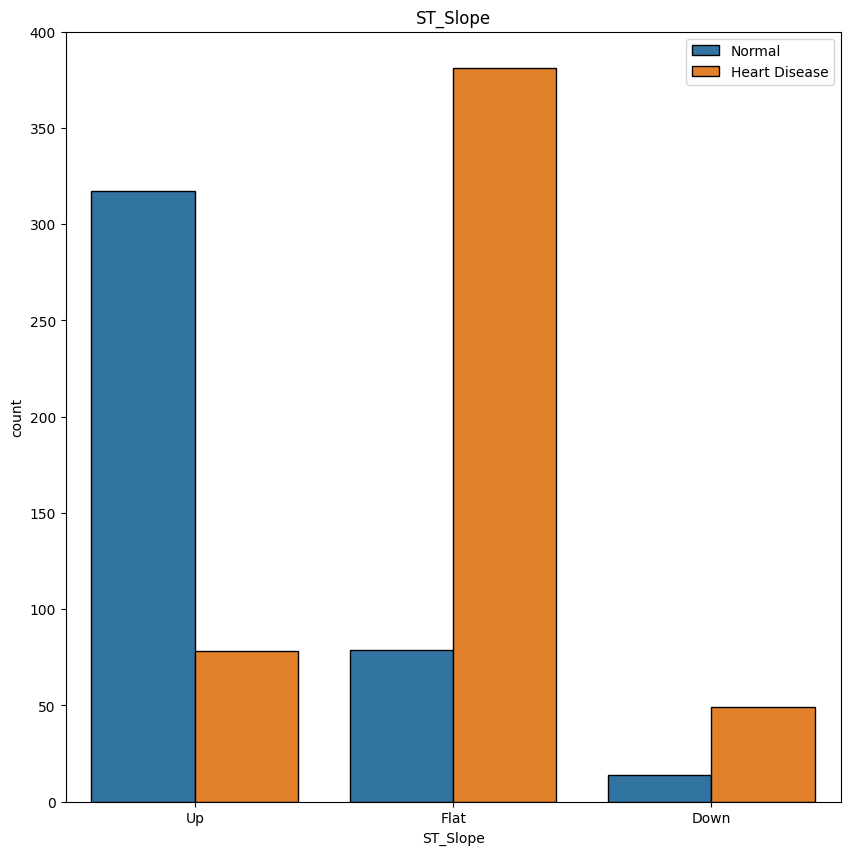

In [11]:
#here we compare betwwen our target and our Categorical features
for i in Categorical:
    plt.figure(figsize=(10,10))
    sns.countplot(x=i, data=df, hue='HeartDisease', edgecolor='black')
    plt.legend(['Normal', 'Heart Disease'])
    plt.title(i)
    plt.show()

# Handeling with outliers :

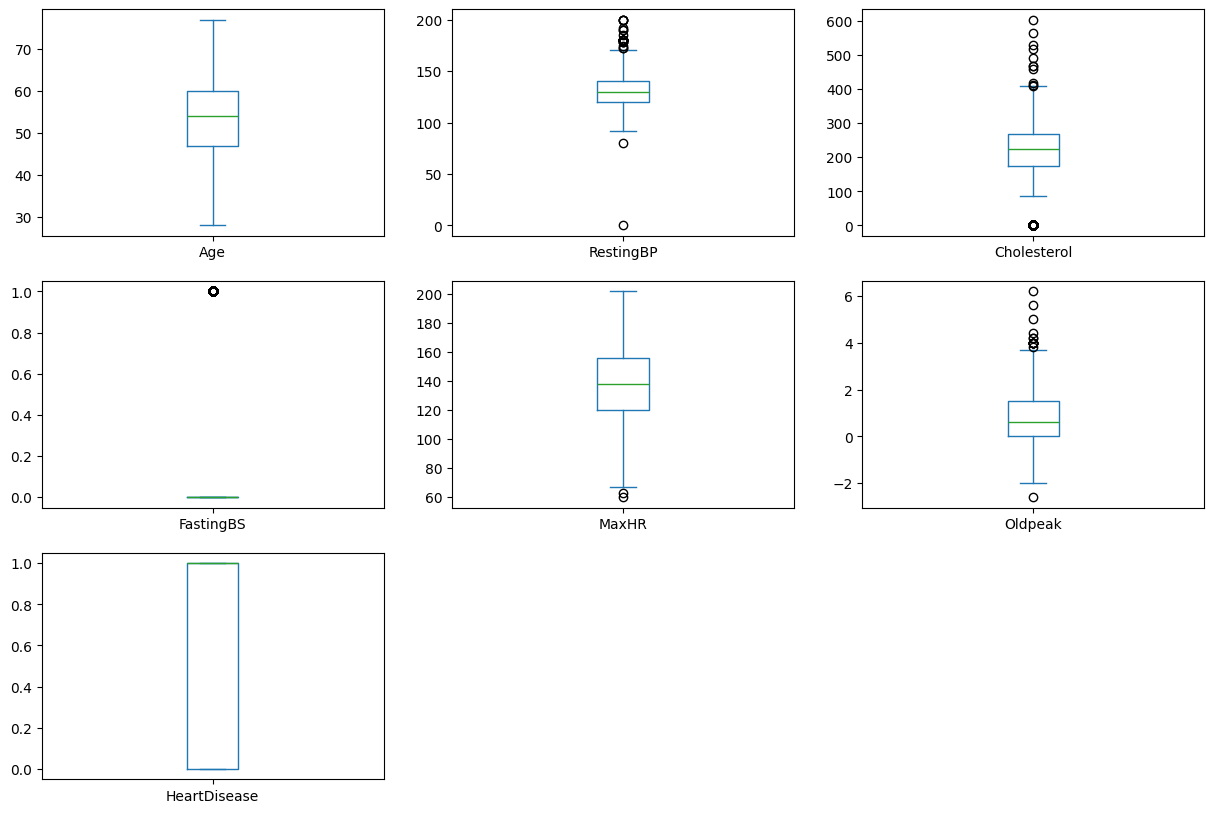

In [12]:
df.plot(kind='box',figsize=(15,10),subplots=True,layout=(3,3))
plt.show()

after the boxplot we find that the outliers here in (age - restingBP-cholesterol-MaxHR-oldpeak)

In [13]:
df_out = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [14]:
#here we are detecting outliers :

def find_outliers_IQR(df):

   q1=df.quantile(0.25)

   q3=df.quantile(0.75)

   IQR=q3-q1

   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]

   return outliers

In [15]:
#here we are trying to find the numbers of outliers and max and min of them to can detect them clearly:
outliers = find_outliers_IQR(df['RestingBP'])
print('number of outliers: '+ str(len(outliers)))

print('max outlier value: '+ str(outliers.max()))

print('min outlier value: '+ str(outliers.min()))

number of outliers: 28
max outlier value: 200
min outlier value: 0


In [16]:
for char in df_out :
    outliers = find_outliers_IQR(df[str(char)])

    print(f"-Check {char} outliers ")

    print('number of outliers: '+ str(len(outliers)))

    print('max outlier value: '+ str(outliers.max()))

    print('min outlier value: '+ str(outliers.min())+ '\n')

-Check Age outliers 
number of outliers: 0
max outlier value: nan
min outlier value: nan

-Check RestingBP outliers 
number of outliers: 28
max outlier value: 200
min outlier value: 0

-Check Cholesterol outliers 
number of outliers: 183
max outlier value: 603
min outlier value: 0

-Check MaxHR outliers 
number of outliers: 2
max outlier value: 63
min outlier value: 60

-Check Oldpeak outliers 
number of outliers: 16
max outlier value: 6.2
min outlier value: -2.6



In [17]:
# remove outliers
def remove_outliers_IQR(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[~((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound))]
    return df_cleaned

df_out = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df = remove_outliers_IQR(df, df_out)
print("Original shape:", df.shape)
print("Shape after outlier removal:", df.shape)

Original shape: (701, 12)
Shape after outlier removal: (701, 12)


# Encoding categorical features:

In [18]:
from sklearn.preprocessing import LabelEncoder
ChestPainType_le = LabelEncoder()
RestingECG_le = LabelEncoder()
ExerciseAngina_le = LabelEncoder()
ST_Slope_le = LabelEncoder()
Sex_le = LabelEncoder()

In [19]:
df['ChestPainType'] = ChestPainType_le.fit_transform(df['ChestPainType'])

In [20]:
ChestPainType_le.classes_

array(['ASY', 'ATA', 'NAP', 'TA'], dtype=object)

In [21]:
df['RestingECG'] = RestingECG_le.fit_transform(df['RestingECG'])


In [22]:
RestingECG_le.classes_

array(['LVH', 'Normal', 'ST'], dtype=object)

In [23]:
df['ST_Slope'] = ST_Slope_le.fit_transform(df['ST_Slope'])

In [24]:
ST_Slope_le.classes_

array(['Down', 'Flat', 'Up'], dtype=object)

In [25]:
df['ExerciseAngina'] = ExerciseAngina_le.fit_transform(df['ExerciseAngina'])

In [26]:
ExerciseAngina_le.classes_

array(['N', 'Y'], dtype=object)

In [27]:
df['Sex'] = Sex_le.fit_transform(df['Sex'])

In [28]:
Sex_le.classes_

array(['F', 'M'], dtype=object)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 701 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             701 non-null    int64  
 1   Sex             701 non-null    int64  
 2   ChestPainType   701 non-null    int64  
 3   RestingBP       701 non-null    int64  
 4   Cholesterol     701 non-null    int64  
 5   FastingBS       701 non-null    int64  
 6   RestingECG      701 non-null    int64  
 7   MaxHR           701 non-null    int64  
 8   ExerciseAngina  701 non-null    int64  
 9   Oldpeak         701 non-null    float64
 10  ST_Slope        701 non-null    int64  
 11  HeartDisease    701 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 71.2 KB


## Spliting data:

In [30]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [32]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler.fit(X)
X_train_std=std_scaler.transform(X_train)
X_test_std=std_scaler.transform(X_test)

X_train = pd.DataFrame(X_train_std, columns=X.columns)
X_test = pd.DataFrame(X_test_std, columns=X.columns)

In [33]:
display(X_train.head())
display(X_test.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,-1.019711,0.561424,-0.897252,0.548422,0.964667,-0.440690,0.113584,-0.228862,1.294439,1.221175,-0.751650
1,-1.124584,0.561424,-0.897252,0.548422,-0.267881,-0.440690,0.113584,1.536838,-0.772535,-0.864955,0.970267
2,1.077758,0.561424,-0.897252,2.494318,-1.241992,-0.440690,0.113584,-2.323064,1.294439,1.742707,-2.473567
3,0.553391,0.561424,1.188896,1.197054,-0.407040,-0.440690,1.706025,-0.926929,1.294439,-0.864955,-0.751650
4,0.658264,-1.781185,-0.897252,-0.100209,1.958658,2.269168,1.706025,-0.434176,1.294439,0.699642,-0.751650


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,0.448517,0.561424,-0.897252,-1.397473,1.899018,-0.44069,0.113584,0.099640,1.294439,2.264240,-0.751650
1,-0.075850,0.561424,-0.897252,0.548422,0.527311,-0.44069,0.113584,-0.269925,1.294439,1.221175,-0.751650
2,-2.278192,0.561424,-0.897252,-0.748841,0.606830,-0.44069,0.113584,0.510268,1.294439,0.699642,-0.751650
3,-0.600217,0.561424,1.188896,0.418696,0.348393,-0.44069,-1.478858,0.633456,-0.772535,-0.864955,0.970267
4,-0.180723,0.561424,-0.897252,0.548422,1.183345,-0.44069,0.113584,1.331524,1.294439,0.803949,0.970267


# Modeling by different methods  :

## Training the Logistic Regression model on the Training set

In [34]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state = 44)
lr.fit(X_train, y_train)

LogisticRegression(random_state=44)

## Predicting the Test set results

In [35]:
y_pred = lr.predict(X_test)
data = pd.DataFrame({"y_test" : y_test , "y_pred": y_pred})
data.head(10)

,y_test,y_pred
895,1,1
174,1,1
56,1,1
853,0,0
818,1,1
597,0,0
785,0,1
883,0,1
523,1,1
558,1,1


## Confusion Matrix and Evaluation


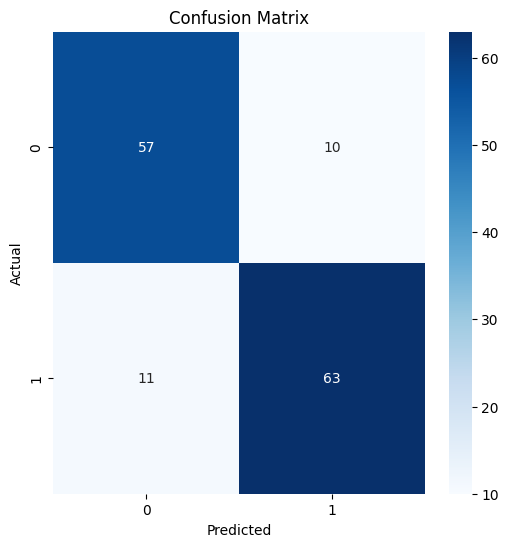

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84        67
           1       0.86      0.85      0.86        74

    accuracy                           0.85       141
   macro avg       0.85      0.85      0.85       141
weighted avg       0.85      0.85      0.85       141

Accuracy: 0.851063829787234


In [36]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm1 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

## Training the K-NN model on the Training set

In [37]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
knn.fit(X_train, y_train)

KNeighborsClassifier()

## Predicting the Test set results

In [38]:
y_pred = knn.predict(X_test)
data = pd.DataFrame({"y_test" : y_test , "y_pred": y_pred})
data.head(10)

,y_test,y_pred
895,1,1
174,1,1
56,1,1
853,0,0
818,1,1
597,0,0
785,0,0
883,0,1
523,1,1
558,1,1


# Confusion Matrix and Evaluation


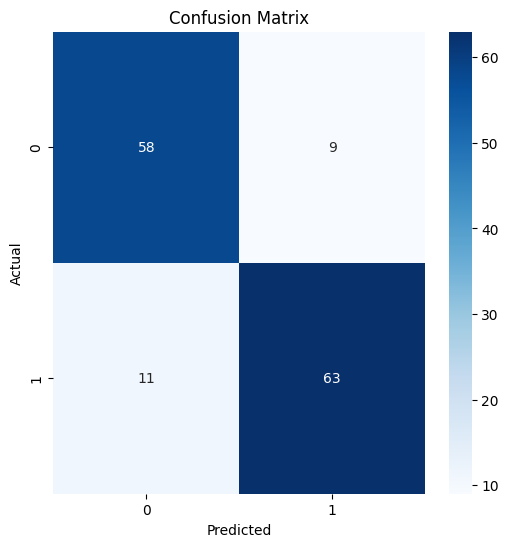

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85        67
           1       0.88      0.85      0.86        74

    accuracy                           0.86       141
   macro avg       0.86      0.86      0.86       141
weighted avg       0.86      0.86      0.86       141

Accuracy: 0.8581560283687943


In [39]:
cm2 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

## Training the SVM model on the Training set

In [40]:
from sklearn.svm import SVC
svm = SVC(kernel = 'linear', random_state = 44)
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=44)

## Predicting the Test set results

In [41]:
y_pred = svm.predict(X_test)
data = pd.DataFrame({"y_test" : y_test , "y_pred": y_pred})
data.head(10)

,y_test,y_pred
895,1,1
174,1,1
56,1,1
853,0,0
818,1,1
597,0,0
785,0,0
883,0,1
523,1,1
558,1,1


## Confusion Matrix and Evaluation


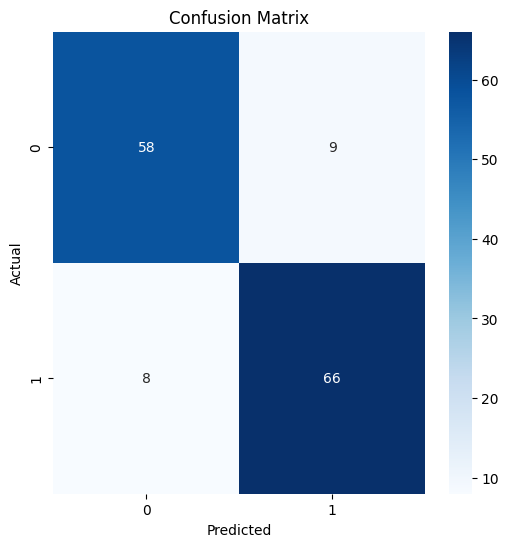

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87        67
           1       0.88      0.89      0.89        74

    accuracy                           0.88       141
   macro avg       0.88      0.88      0.88       141
weighted avg       0.88      0.88      0.88       141

Accuracy: 0.8794326241134752


In [42]:
cm3 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

## Training the Kernel SVM model on the Training set

In [43]:
from sklearn.svm import SVC
k_svm = SVC(kernel = 'rbf', random_state = 44)
k_svm.fit(X_train, y_train)

SVC(random_state=44)

## Predicting the Test set results

In [44]:
y_pred = k_svm.predict(X_test)
data = pd.DataFrame({"y_test" : y_test , "y_pred": y_pred})
data.head(10)

,y_test,y_pred
895,1,1
174,1,1
56,1,1
853,0,0
818,1,1
597,0,0
785,0,1
883,0,1
523,1,1
558,1,1


## Confusion Matrix and Evaluation


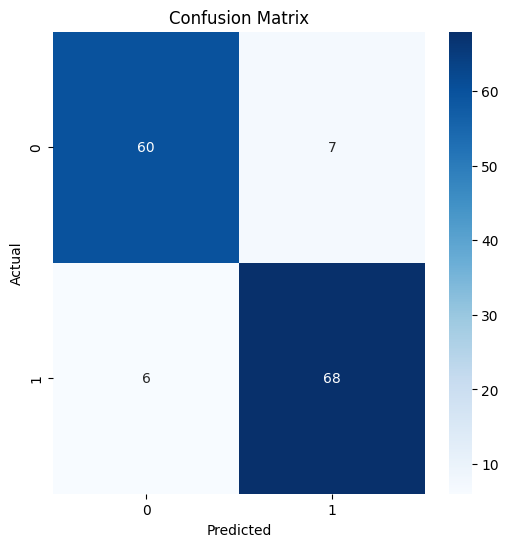

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.90        67
           1       0.91      0.92      0.91        74

    accuracy                           0.91       141
   macro avg       0.91      0.91      0.91       141
weighted avg       0.91      0.91      0.91       141

Accuracy: 0.9078014184397163


In [45]:
cm4 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

## Training the Naive Bayes model on the Training set

In [46]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

## Predicting the Test set results

In [47]:
y_pred = nb.predict(X_test)
data = pd.DataFrame({"y_test" : y_test , "y_pred": y_pred})
data.head(10)

,y_test,y_pred
895,1,1
174,1,1
56,1,1
853,0,0
818,1,1
597,0,0
785,0,1
883,0,1
523,1,1
558,1,1


## Confusion Matrix and Evaluation


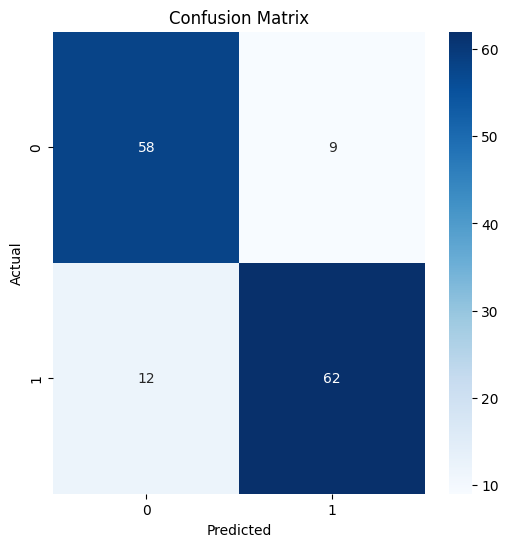

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85        67
           1       0.87      0.84      0.86        74

    accuracy                           0.85       141
   macro avg       0.85      0.85      0.85       141
weighted avg       0.85      0.85      0.85       141

Accuracy: 0.851063829787234


In [48]:
cm5 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

## Training the Decision Tree Classification model on the Training set

In [49]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 44)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=44)

## Predicting the Test set results

In [50]:
y_pred = dt.predict(X_test)
data = pd.DataFrame({"y_test" : y_test , "y_pred": y_pred})
data.head(10)

,y_test,y_pred
895,1,1
174,1,1
56,1,1
853,0,0
818,1,0
597,0,0
785,0,1
883,0,1
523,1,1
558,1,1


## Confusion Matrix and Evaluation


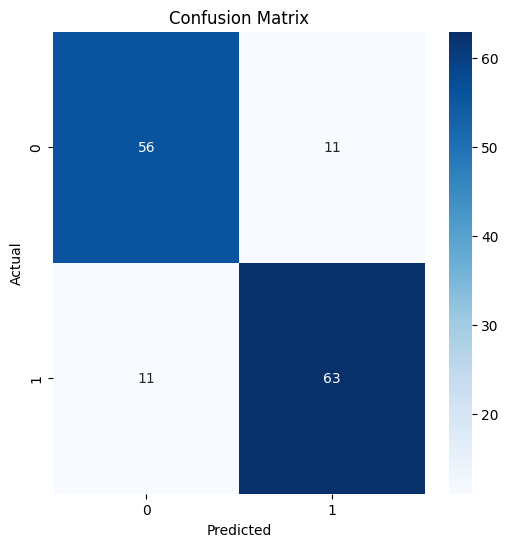

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84        67
           1       0.85      0.85      0.85        74

    accuracy                           0.84       141
   macro avg       0.84      0.84      0.84       141
weighted avg       0.84      0.84      0.84       141

Accuracy: 0.8439716312056738


In [51]:
cm6 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm6, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

## Training the Random Forest Classification model on the Training set

In [52]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 44)
rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=44)

## Predicting the Test set results

In [53]:
y_pred = rf.predict(X_test)
data = pd.DataFrame({"y_test" : y_test , "y_pred": y_pred})
data.head(10)

,y_test,y_pred
895,1,1
174,1,1
56,1,1
853,0,0
818,1,0
597,0,0
785,0,1
883,0,1
523,1,1
558,1,1


## Confusion Matrix and Evaluation


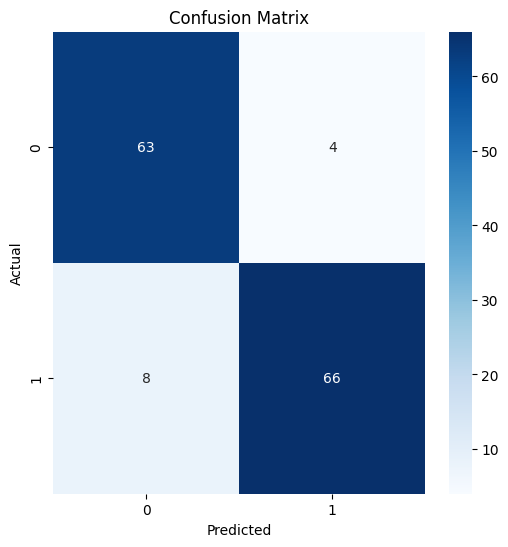

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91        67
           1       0.94      0.89      0.92        74

    accuracy                           0.91       141
   macro avg       0.92      0.92      0.91       141
weighted avg       0.92      0.91      0.91       141

Accuracy: 0.9148936170212766


In [54]:
cm7 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm7, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Magdy Mohamed